# Séance 5 · Notebook 3 : apprentissage automatique

PSY2007D — Laboratoire 1, automne 2026

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Prétraitement et BIDS</div><div style="font-size:0.85em; color:#5B6472;">télécharger · organiser · nettoyer</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Caractéristiques</div><div style="font-size:0.85em; color:#5B6472;">ERP · spectres · temps-fréquence · 1/f · complexité · connectivité</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Apprentissage automatique</div><div style="font-size:0.85em; color:#C9D6E8;">décoder repos/mouvement et gauche/droite</div></td></tr></table>

Un modèle d'**apprentissage automatique** (*machine learning*) apprend, à partir d'exemples étiquetés, à prédire l'étiquette d'un nouvel exemple. Ici, un exemple est un essai d'EEG résumé par ses caractéristiques (notebook 2), et l'étiquette est ce que faisait la personne. Deux questions :

1. **Repos ou mouvement ?** La réponse devrait se lire dans la baisse de puissance μ et β au-dessus du cortex moteur.
2. **Main gauche ou main droite ?** Plus difficile : il faut détecter de quel côté la baisse est la plus forte.

Pour chaque question, on compare plusieurs façons de construire le modèle : une seule caractéristique ou plusieurs, un capteur ou plusieurs, un modèle pour chaque capteur.

| Partie | Contenu |
|---|---|
| 0 | Charger le tableau du notebook 2 |
| 1 | Le principe : entraîner, tester, comparer au hasard |
| 2 | Repos ou mouvement : caractéristiques, capteurs, un modèle par capteur, une nouvelle personne |
| 3 | Main gauche ou main droite : spectre, ERP et le piège des yeux |
| 4 | Récapitulatif |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Trois types de blocs</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;le code est complet : exécutez la cellule et lisez les commentaires.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complétez une ou deux lignes marquées <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;écrivez la cellule vous-même, à partir des indices et des liens vers la documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Chaque exercice est suivi d'une solution repliée : essayez d'abord.</div></div>

In [ ]:
# ---- Installation (Colab seulement), imports et dossier des données
import sys
from pathlib import Path

DANS_COLAB = "google.colab" in sys.modules
if DANS_COLAB:
    !pip install -q mne mne-bids "mne-denoise[mne,viz]" antropy specparam==2.0.0rc7
    !wget -q -N https://raw.githubusercontent.com/thecocolab/PSY2007D-UdeM/main/outils_seance5.py
    from google.colab import drive
    drive.mount("/content/drive")
    DOSSIER = Path("/content/drive/MyDrive/PSY2007D/donnees_seance5")
else:
    DOSSIER = Path("donnees_seance5")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import sklearn
import outils_seance5 as outils

mne.set_log_level("WARNING")
COULEURS = {"repos": "#2a78d6", "mouvement": "#eb6834", "gauche": "#1baf7a", "droite": "#4a3aa7"}
print("scikit-learn", sklearn.__version__, "| MNE", mne.__version__)

## 0. Charger le tableau des caractéristiques

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Lire le fichier CSV du notebook 2

Si le fichier n'existe pas, la cellule refait les notebooks 1 et 2 automatiquement (quelques minutes).

In [ ]:
# ---- Le tableau : une ligne par essai
fichier = outils.chemin_caracteristiques(DOSSIER)
if not fichier.exists():
    print("Tableau du notebook 2 introuvable : préparation automatique...")
    outils.preparer_caracteristiques(DOSSIER)

df = pd.read_csv(fichier).copy()          # .copy() regroupe les colonnes en mémoire (évite un avertissement de pandas)
SUJETS = sorted(df["sujet"].unique())
CANAUX = [col[len("mu_"):] for col in df.columns if col.startswith("mu_")]      # les 64 canaux
print(df.shape[0], "essais,", len(SUJETS), "participants,", len(CANAUX), "canaux")
df[["sujet", "essai", "condition", "mouvement", "mu_C3", "beta_C3", "expo_C3", "pe_C3", "erp300_C3"]].head()

In [ ]:
# ---- Un petit outil pour nommer les colonnes : mesures × canaux
def colonnes(mesures, canaux):
    """colonnes(["mu", "beta"], ["C3"]) -> ["mu_C3", "beta_C3"]"""
    return [f"{m}_{c}" for m in mesures for c in canaux]


print(colonnes(["mu", "beta"], ["C3", "C4"]))
print(len(colonnes(["mu"], CANAUX)), "colonnes pour la puissance μ de tous les canaux")

## 1. Le principe

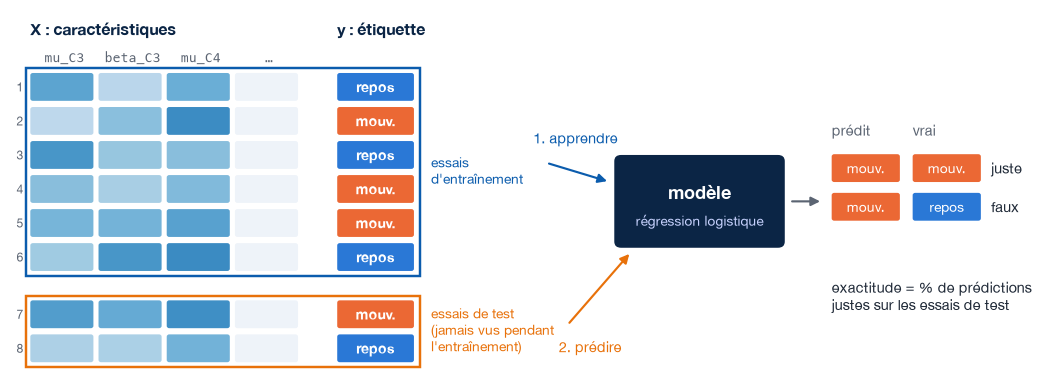

| Mot | Sens ici |
|---|---|
| caractéristiques (**X**) | les colonnes choisies du tableau, par exemple `mu_C3` |
| étiquette (**y**) | ce qu'on veut deviner : 0 = repos, 1 = mouvement |
| entraînement | le modèle ajuste ses paramètres sur une partie des essais |
| test | on mesure ses prédictions sur des essais qu'il n'a **jamais vus** |
| exactitude | proportion de prédictions justes sur les essais de test |
| hasard | l'exactitude qu'on obtiendrait en répondant au hasard (environ 50 % ici) |

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : régression logistique</b><br>La <b>régression logistique</b> combine les caractéristiques en une somme pondérée, puis transforme cette somme en probabilité (entre 0 et 1) d'appartenir à la classe 1. Avec une seule caractéristique, cela revient à placer un <b>seuil</b> : au-dessous, « mouvement » ; au-dessus, « repos ». L'entraînement choisit les poids (et donc le seuil) qui séparent le mieux les essais d'entraînement.</div>

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : scikit-learn</b><br><b>scikit-learn</b> est la bibliothèque de référence pour l'apprentissage automatique en Python (Pedregosa et al., 2011). Tous ses modèles s'utilisent de la même façon : <code>modele.fit(X, y)</code> pour entraîner, <code>modele.predict(X)</code> pour prédire, <code>modele.score(X, y)</code> pour l'exactitude. <a href='https://scikit-learn.org/stable/'>Documentation</a></div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Un participant, une caractéristique

S001, la puissance μ à C3 (`mu_C3`). Au notebook 2, on a vu que les deux distributions se chevauchent : on s'attend à un modèle meilleur que le hasard, mais loin de la perfection.

In [ ]:
# ---- Données de S001 : X (essais × caractéristiques) et y (étiquettes)
s001 = df[df["sujet"] == 1]
X = s001[["mu_C3"]].to_numpy()                 # double crochet : X reste un tableau à 2 dimensions
y = s001["mouvement"].to_numpy()               # 0 = repos, 1 = mouvement
print("X :", X.shape, "| y :", y.shape, "| mouvements :", y.sum(), "| repos :", (y == 0).sum())

In [ ]:
# ---- Séparer : 75 % pour l'entraînement, 25 % pour le test
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_entr, X_test, y_entr, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
modele = LogisticRegression()
modele.fit(X_entr, y_entr)                     # 1. apprendre
predictions = modele.predict(X_test)           # 2. prédire des essais jamais vus
print("Prédictions :", predictions)
print("Vraies      :", y_test)
print("Exactitude sur le test : %.2f" % modele.score(X_test, y_test))

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> La validation croisée

Avec seulement 22 essais de test, l'exactitude dépend beaucoup des essais tirés au sort (changez `random_state` pour le voir). La **validation croisée** répète l'opération : on coupe les essais en 5 parts (des *plis*), chaque part sert une fois de test, et on fait la moyenne. Tous les essais servent au test, une fois chacun.

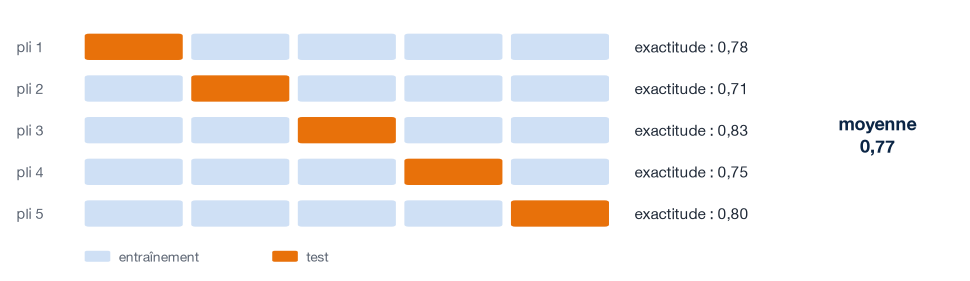

Dans la même foulée, on **standardise** chaque caractéristique (moyenne 0, écart-type 1) avant la régression : indispensable quand les caractéristiques n'ont pas les mêmes unités (µV²/Hz, µV, entropie, ...). Le `make_pipeline` garantit que cette standardisation est apprise **sur les essais d'entraînement seulement**.

In [ ]:
# ---- Un modèle = standardiser, puis régression logistique ; évaluation en 5 plis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score


def nouveau_modele(C=1.0):
    """Standardiser chaque caractéristique, puis régression logistique (C : voir partie 2)."""
    return make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))


plis = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)       # « stratifié » : même proportion de classes dans chaque pli
scores = cross_val_score(nouveau_modele(), X, y, cv=plis)
print("Exactitude par pli :", np.round(scores, 2))
print("Moyenne : %.2f ± %.2f" % (scores.mean(), scores.std()))

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Faire mieux que le hasard, vraiment ?

Répondre toujours « mouvement » donne déjà environ 52 % (il y a un peu plus d'essais de mouvement). Et avec peu d'essais, un modèle sans aucune information peut dépasser 50 % par chance. Le **test de permutation** mesure ce que la chance peut produire : on mélange les étiquettes au hasard (le lien entre X et y est détruit), on refait la validation croisée, et on recommence 200 fois.

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce que dit la littérature</b><br>Avec une centaine d'essais, le seuil de « vrai » succès n'est pas 50 % mais plutôt 58 à 60 % (Combrisson et Jerbi, 2015). Une exactitude de 55 % sur 87 essais ne prouve rien.</div>

In [ ]:
# ---- Deux références : la réponse la plus fréquente, et des étiquettes mélangées au hasard
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import permutation_test_score

print("Toujours la classe la plus fréquente : %.2f" % cross_val_score(DummyClassifier(), X, y, cv=plis).mean())

score, scores_hasard, p = permutation_test_score(nouveau_modele(), X, y, cv=plis, n_permutations=200, random_state=0)
plt.figure(figsize=(7, 3))
plt.hist(scores_hasard, bins=20, color="#C3C9D2", label="étiquettes mélangées (200 fois)")
plt.axvline(score, color="#E8710A", lw=2.5, label=f"vraies étiquettes : {score:.2f}")
plt.axvline(np.percentile(scores_hasard, 95), color="#0B2545", lw=1, label="95 % du hasard")
plt.xlabel("exactitude"); plt.ylabel("nombre"); plt.legend(frameon=False, fontsize=9)
plt.title(f"S001, mu_C3 : p = {p:.3f}")
plt.show()

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

Même évaluation (validation croisée 5 plis) pour S001, mais avec la puissance **β à C3** au lieu de μ. Laquelle des deux bandes distingue le mieux repos et mouvement ?

In [ ]:
# ---- Exercice
# X_beta = s001[[...]].to_numpy()                              # <--- à compléter
# print("β à C3 : %.2f" % cross_val_score(nouveau_modele(), X_beta, y, cv=plis).mean())

In [ ]:
#@title Solution (à consulter après avoir essayé)
X_beta = s001[["beta_C3"]].to_numpy()
print("β à C3 : %.2f" % cross_val_score(nouveau_modele(), X_beta, y, cv=plis).mean())

## 2. Repos ou mouvement ?

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Un modèle par personne, pour toutes les personnes

La fonction `score_intra` refait la validation croisée pour chaque participant séparément, avec les colonnes choisies, et renvoie une exactitude par personne. On l'utilisera dans toute la suite.

In [ ]:
# ---- Exactitude de chaque participant, pour une question et une liste de colonnes
def essais_et_etiquettes(tableau, question):
    """Garde les essais utiles et renvoie (essais, y) pour une question."""
    if question == "repos/mouvement":
        return tableau, tableau["mouvement"].to_numpy()
    mouvements = tableau[tableau["mouvement"] == 1]                    # gauche/droite : seulement les mouvements
    return mouvements, (mouvements["condition"] == "droite").astype(int).to_numpy()


def score_intra(cols, question="repos/mouvement", C=1.0):
    """Validation croisée (5 plis) dans chaque participant ; une exactitude par personne."""
    resultats = {}
    for sujet, essais in df.groupby("sujet"):
        essais, y = essais_et_etiquettes(essais, question)
        plis = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
        resultats[sujet] = cross_val_score(nouveau_modele(C), essais[cols].to_numpy(), y, cv=plis).mean()
    return pd.Series(resultats)


mu_c3 = score_intra(["mu_C3"])
print(mu_c3.round(2).to_dict())
print("Moyenne : %.2f" % mu_c3.mean())

In [ ]:
#@title Fonction de figure : comparer des modèles (exécuter ; pas besoin de lire le code)
from scipy.stats import binom

RESULTATS = []          # tous les scores de la séance, pour le récapitulatif


def comparer(scores, titre, question="repos/mouvement"):
    """Une barre par modèle (moyenne des participants) et un point par participant."""
    noms = list(scores)
    fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(noms) + 1.3))
    for k, nom in enumerate(noms):
        s = scores[nom]
        ax.barh(k, s.mean(), color="#0B5CAD" if k == int(np.argmax([scores[n].mean() for n in noms])) else "#9DB8DA",
                height=0.6, zorder=2)
        ax.scatter(s.to_numpy(), np.full(len(s), k), s=12, color="#0B2545", alpha=0.6, zorder=3)
        ax.text(1.005, k, f"{s.mean():.2f}".replace(".", ","), va="center", fontsize=10, color="#1F2937",
                transform=ax.get_yaxis_transform())
        RESULTATS.append({"question": question, "modèle": nom, "exactitude": s.mean()})
    n_essais = len(essais_et_etiquettes(df[df["sujet"] == SUJETS[0]], question)[0])
    seuil = binom.ppf(0.95, n_essais, 0.5) / n_essais
    ax.axvline(0.5, color="#5B6472", lw=1, zorder=1)
    ax.axvline(seuil, color="#E8710A", lw=1, zorder=1)
    ax.set_yticks(range(len(noms)), noms); ax.set_ylim(len(noms) - 0.5, -1.0)
    ax.text(seuil, -0.75, f" seuil du hasard (p < 0,05, {n_essais} essais)", color="#E8710A", fontsize=8.5, va="center")
    ax.set_xlim(0.3, 1.0); ax.set_xlabel("exactitude (validation croisée)")
    ax.set_title(titre, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Combiner des caractéristiques (un seul capteur : C3)

Chaque caractéristique capte un aspect différent du signal. Les combiner aide-t-il ?

In [ ]:
# ---- À C3 : une caractéristique, puis des combinaisons
modeles_c3 = {
    "μ": ["mu_C3"],
    "β": ["beta_C3"],
    "θ": ["theta_C3"],
    "μ + β": ["mu_C3", "beta_C3"],
    "θ + μ + β": ["theta_C3", "mu_C3", "beta_C3"],
    "θ + μ + β + 1/f": ["theta_C3", "mu_C3", "beta_C3", "expo_C3"],
    "θ + μ + β + 1/f + PE + LZ": ["theta_C3", "mu_C3", "beta_C3", "expo_C3", "pe_C3", "lz_C3"],
}
comparer({nom: score_intra(cols) for nom, cols in modeles_c3.items()}, "Repos ou mouvement : caractéristiques de C3")

La puissance **β** seule fait déjà mieux que la puissance μ, et les combinaisons n'apportent qu'un peu plus : les bandes voisines portent en partie la même information (quand μ baisse, β baisse aussi). Ajouter une caractéristique n'aide que si elle apporte une information **nouvelle**.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

Même comparaison à **Cz** (au sommet de la tête) : complétez la liste des canaux. Cz fait-il mieux ou moins bien que C3 ?

In [ ]:
# ---- Exercice
# modeles_cz = {"μ + β (Cz)": colonnes(["mu", "beta"], [...])}          # <--- à compléter
# comparer({nom: score_intra(cols) for nom, cols in modeles_cz.items()}, "Cz")

In [ ]:
#@title Solution (à consulter après avoir essayé)
modeles_cz = {"μ + β (Cz)": colonnes(["mu", "beta"], ["Cz"]), "μ + β (C3)": colonnes(["mu", "beta"], ["C3"])}
comparer({nom: score_intra(cols) for nom, cols in modeles_cz.items()}, "Cz vs C3")

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Un capteur, deux capteurs, tous les capteurs

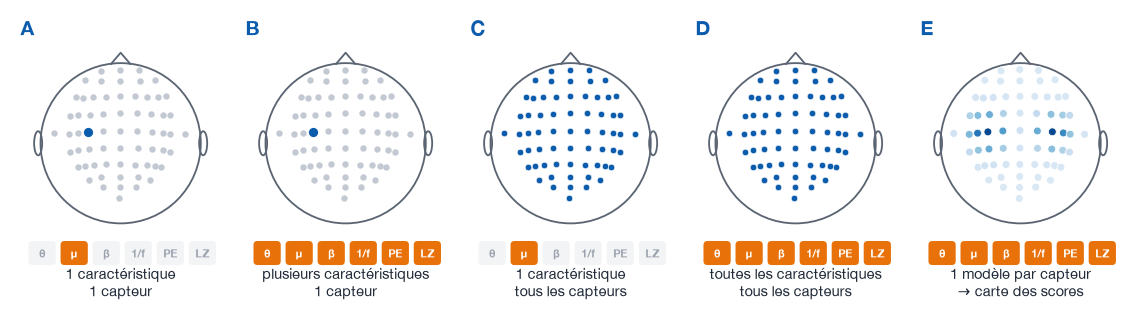

On garde μ et β, et on augmente le nombre de capteurs (stratégies A à D).

In [ ]:
# ---- Plus de capteurs
modeles_capteurs = {
    "μ + β, C3 (2 colonnes)": colonnes(["mu", "beta"], ["C3"]),
    "μ + β, C3 et C4 (4)": colonnes(["mu", "beta"], ["C3", "C4"]),
    "μ + β, 64 canaux (128)": colonnes(["mu", "beta"], CANAUX),
    "θ + μ + β, 64 canaux (192)": colonnes(["theta", "mu", "beta"], CANAUX),
    "tout, 64 canaux (512)": colonnes(["theta", "mu", "beta", "expo", "pe", "lz", "erp100", "erp300"], CANAUX),
}
comparer({nom: score_intra(cols) for nom, cols in modeles_capteurs.items()}, "Repos ou mouvement : nombre de capteurs")

Tous les capteurs ensemble font mieux qu'un seul. Mais le dernier modèle, avec **512 colonnes** pour moins de 90 essais, ne fait guère mieux qu'avec 128 colonnes. Avec plus de caractéristiques que d'essais, le modèle risque d'apprendre par cœur les particularités des essais d'entraînement (du bruit) au lieu de la règle générale : c'est le **surapprentissage**. On en verra un exemple net en partie 3.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : surapprentissage et régularisation</b><br>Le paramètre <code>C</code> de la régression logistique règle la <b>régularisation</b> : plus <code>C</code> est petit, plus le modèle est obligé de garder des poids faibles, donc de rester simple. Avec beaucoup de caractéristiques et peu d'essais, un <code>C</code> plus petit aide souvent.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : la régularisation

Refaites le modèle « tout, 64 canaux » avec `C=0.01`, puis `C=100`. Lequel s'en sort le mieux ?

In [ ]:
# ---- Exercice
tout = colonnes(["theta", "mu", "beta", "expo", "pe", "lz", "erp100", "erp300"], CANAUX)
# comparer({f"C = {c}": score_intra(tout, C=c) for c in [...]}, "Régularisation")      # <--- à compléter

In [ ]:
#@title Solution (à consulter après avoir essayé)
comparer({f"C = {c}": score_intra(tout, C=c) for c in [0.01, 1, 100]}, "Régularisation (512 colonnes)")
# Ici l'écart est faible : la régression logistique de scikit-learn est déjà régularisée par défaut (C = 1),
# et la standardisation met toutes les colonnes à la même échelle.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Un modèle par capteur : une carte des scores

Stratégie E : pour chacun des 64 canaux, un modèle avec ses propres caractéristiques spectrales (θ, μ, β), puis on dessine l'exactitude de chaque canal sur la tête. C'est une façon de demander au modèle **où** se trouve l'information. Environ 10 secondes.

In [ ]:
# ---- 64 modèles (un par canal), puis carte
info = mne.create_info(CANAUX, sfreq=100, ch_types="eeg")
info.set_montage("colin27_1005")

carte_rm = np.array([score_intra(colonnes(["theta", "mu", "beta"], [canal])).mean() for canal in CANAUX])

fig, ax = plt.subplots(figsize=(4.2, 4))
im, _ = mne.viz.plot_topomap(carte_rm, info, axes=ax, cmap="Reds", vlim=(0.5, carte_rm.max()), show=False,
                             names=[c if c in ("C3", "C4", "Cz", "Oz", "Fp1", "Fp2") else "" for c in CANAUX])
fig.colorbar(im, ax=ax, shrink=0.75, label="exactitude")
ax.set_title("Repos ou mouvement : un modèle par canal")
plt.show()
meilleurs = pd.Series(carte_rm, index=CANAUX).sort_values(ascending=False)
print("Les 6 meilleurs canaux :", meilleurs.head(6).round(2).to_dict())

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe (et ce que dit la littérature)</b><br>Les canaux qui décodent le mieux sont au-dessus du <b>cortex sensorimoteur</b> (autour de C3, CP3, C4), là où la désynchronisation μ/β est la plus forte (notebook 2). La carte des scores retrouve la physiologie : c'est un bon signe que le modèle utilise l'activité du cerveau, et pas un artefact.</div>

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : une carte par famille de caractéristiques

Objectif : la même carte, mais avec l'**entropie de permutation** (`pe`) seule, puis avec l'**exposant apériodique** (`expo`) seul. Les régions informatives sont-elles les mêmes que pour le spectre ?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Reprenez la cellule précédente et remplacez <code>["theta", "mu", "beta"]</code> par <code>["pe"]</code>, puis <code>["expo"]</code>.</li><li>Une figure à deux panneaux : <code>fig, axes = plt.subplots(1, 2)</code> et <code>axes=axes[0]</code>, <code>axes=axes[1]</code>.</li><li>Gardez la même échelle de couleurs (<code>vlim=(0.5, 0.8)</code>) pour comparer.</li><li>Documentation : <a href='https://mne.tools/stable/generated/mne.viz.plot_topomap.html'>plot_topomap</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
for ax, mesure in zip(axes, ["pe", "expo"]):
    carte = np.array([score_intra([f"{mesure}_{canal}"]).mean() for canal in CANAUX])
    im, _ = mne.viz.plot_topomap(carte, info, axes=ax, cmap="Reds", vlim=(0.5, 0.8), show=False)
    ax.set_title(mesure)
fig.colorbar(im, ax=axes, shrink=0.7, label="exactitude")
plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Une famille de caractéristiques à la fois (tous les capteurs)

In [ ]:
# ---- Chaque famille de mesures du notebook 2, sur les 64 canaux
familles = {
    "spectre (θ, μ, β)": colonnes(["theta", "mu", "beta"], CANAUX),
    "apériodique (1/f)": colonnes(["expo"], CANAUX),
    "entropie de permutation": colonnes(["pe"], CANAUX),
    "Lempel-Ziv": colonnes(["lz"], CANAUX),
    "ERP (100-200 et 300-500 ms)": colonnes(["erp100", "erp300"], CANAUX),
}
comparer({nom: score_intra(cols) for nom, cols in familles.items()}, "Repos ou mouvement : familles de caractéristiques")

Le **spectre** l'emporte nettement : c'est lui qui capte le plus directement la désynchronisation. L'entropie de permutation et Lempel-Ziv font mieux que le hasard, en partie parce qu'elles dépendent elles aussi du spectre (notebook 2). L'exposant apériodique, qui ne change pas de façon régulière entre repos et mouvement, apporte peu.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Une nouvelle personne : intra-sujet ou inter-sujets ?

Jusqu'ici, chaque modèle était entraîné et testé sur **la même personne**. Une application réelle (une interface cerveau-machine, un outil clinique) voudrait un modèle qui fonctionne **sur quelqu'un de nouveau**, sans réentraînement.

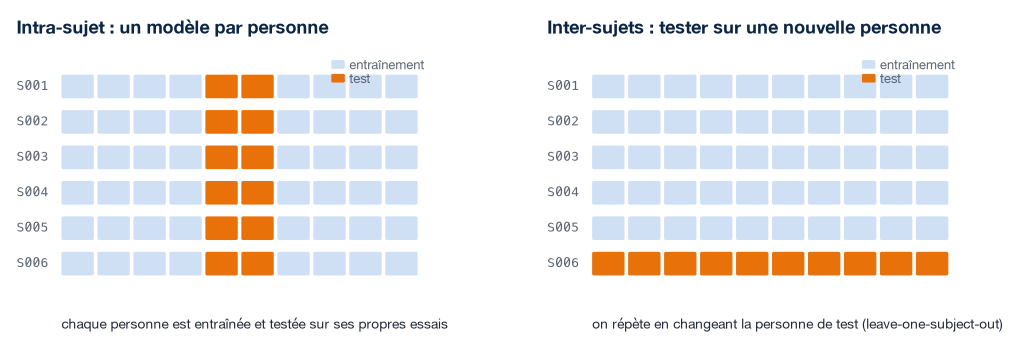

Les niveaux de puissance varient beaucoup d'une personne à l'autre (épaisseur du crâne, position du casque). On **centre-réduit** donc chaque caractéristique séparément pour chaque personne, sans utiliser les étiquettes.

In [ ]:
# ---- Entraîner sur toutes les personnes sauf une, tester sur celle-là, et recommencer
from sklearn.model_selection import LeaveOneGroupOut


def score_inter(cols, question="repos/mouvement"):
    """Leave-one-subject-out ; une exactitude par personne laissée de côté."""
    essais, y = essais_et_etiquettes(df, question)
    X = essais.groupby("sujet")[cols].transform(lambda v: (v - v.mean()) / v.std()).to_numpy()
    groupes = essais["sujet"].to_numpy()
    scores = cross_val_score(nouveau_modele(), X, y, cv=LeaveOneGroupOut(), groups=groupes)
    return pd.Series(scores, index=np.unique(groupes))


spectre_64 = colonnes(["theta", "mu", "beta"], CANAUX)
comparer({"intra-sujet (spectre, 64 canaux)": score_intra(spectre_64),
          "inter-sujets (spectre, 64 canaux)": score_inter(spectre_64),
          "intra-sujet (μ + β, C3 et C4)": score_intra(colonnes(["mu", "beta"], ["C3", "C4"])),
          "inter-sujets (μ + β, C3 et C4)": score_inter(colonnes(["mu", "beta"], ["C3", "C4"]))},
         "Repos ou mouvement : une personne nouvelle")

Tester sur une nouvelle personne coûte en exactitude, surtout avec 64 canaux : la carte exacte des effets varie d'une personne à l'autre, et un modèle à 192 colonnes apprend les particularités des personnes d'entraînement. Avec seulement C3 et C4, là où l'effet est le même chez presque tout le monde, la perte est plus faible. Les interfaces cerveau-machine sont presque toujours **calibrées** pour chaque utilisateur, et certaines personnes restent difficiles à décoder (Blankertz et al., 2010).

## 3. Main gauche ou main droite ?

On ne garde que les essais de mouvement (environ 22 par main et par personne) : c'est peu.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Avec le spectre

In [ ]:
# ---- Spectre : C3 et C4, puis tous les canaux
modeles_lr = {
    "μ + β, C3 et C4": colonnes(["mu", "beta"], ["C3", "C4"]),
    "μ + β, 64 canaux": colonnes(["mu", "beta"], CANAUX),
    "θ + μ + β, 64 canaux": colonnes(["theta", "mu", "beta"], CANAUX),
}
comparer({nom: score_intra(cols, "gauche/droite") for nom, cols in modeles_lr.items()},
         "Gauche ou droite : spectre", question="gauche/droite")

Le score est faible, proche du seuil du hasard, avec de grandes différences entre personnes. C'est cohérent avec le notebook 2 : la différence de désynchronisation entre C3 et C4 est modeste, surtout pour la main gauche, et 45 essais, c'est peu. Les études de décodage gauche/droite utilisent souvent des filtres spatiaux (voir le bloc Type 3 plus bas) et bien plus d'essais.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Avec l'ERP

In [ ]:
# ---- ERP : amplitude 300-500 ms, à C3 et C4 puis sur tous les canaux
modeles_erp = {
    "ERP 300-500 ms, C3 et C4": colonnes(["erp300"], ["C3", "C4"]),
    "ERP 300-500 ms, 64 canaux": colonnes(["erp300"], CANAUX),
    "ERP 100-200 ms, 64 canaux": colonnes(["erp100"], CANAUX),
    "tout, 64 canaux (512)": colonnes(["theta", "mu", "beta", "expo", "pe", "lz", "erp100", "erp300"], CANAUX),
}
comparer({nom: score_intra(cols, "gauche/droite") for nom, cols in modeles_erp.items()},
         "Gauche ou droite : ERP", question="gauche/droite")

Deux remarques. L'ERP précoce (100-200 ms) ne décode rien, alors que l'ERP de 300-500 ms décode très bien. Et le modèle avec **toutes** les caractéristiques (512 colonnes pour 45 essais) fait **moins bien** que l'ERP seul : les 448 colonnes inutiles pour cette question ajoutent du bruit que le modèle apprend par cœur (surapprentissage).

Beaucoup mieux que le spectre, donc. Trop beau ? Au notebook 2, la différence gauche - droite de l'ERP était surtout **à l'avant de la tête** : les yeux. Demandons au modèle où il trouve l'information.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Le piège des yeux

In [ ]:
# ---- Un modèle ERP par canal : où se trouve l'information gauche/droite ?
carte_lr = np.array([score_intra([f"erp300_{canal}"], "gauche/droite").mean() for canal in CANAUX])

fig, ax = plt.subplots(figsize=(4.2, 4))
im, _ = mne.viz.plot_topomap(carte_lr, info, axes=ax, cmap="Reds", vlim=(0.5, carte_lr.max()), show=False,
                             names=[c if c in ("F7", "F8", "C3", "C4", "Oz") else "" for c in CANAUX])
fig.colorbar(im, ax=ax, shrink=0.75, label="exactitude")
ax.set_title("Gauche ou droite : un modèle ERP par canal")
plt.show()
print("Les 6 meilleurs canaux :", pd.Series(carte_lr, index=CANAUX).sort_values(ascending=False).head(6).round(2).to_dict())

Les meilleurs canaux sont **à l'avant, sur les côtés** (F7, F8, AF8), juste à côté des yeux. C3 et C4 décodent aussi, mais au notebook 2 on a vu que le signal des yeux s'étend jusque-là. La personne regarde la cible, à gauche ou à droite : le modèle a surtout appris **la direction du regard**.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : un seul signal, les yeux

Construisez une seule caractéristique, `heog` = `erp300_F8` − `erp300_F7` (le « signal des yeux » du notebook 2), et évaluez-la seule pour la question gauche/droite. Comparez avec le modèle ERP à 64 canaux.

In [ ]:
# ---- Exercice
# df["heog"] = df[...] - df[...]                                   # <--- à compléter
# comparer({"yeux seuls (F8 - F7)": score_intra(["heog"], "gauche/droite"),
#           "ERP 300-500 ms, 64 canaux": score_intra(colonnes(["erp300"], CANAUX), "gauche/droite")},
#          "Gauche ou droite : les yeux", question="gauche/droite")

In [ ]:
#@title Solution (à consulter après avoir essayé)
df["heog"] = df["erp300_F8"] - df["erp300_F7"]
comparer({"yeux seuls (F8 - F7)": score_intra(["heog"], "gauche/droite"),
          "ERP 300-500 ms, 64 canaux": score_intra(colonnes(["erp300"], CANAUX), "gauche/droite")},
         "Gauche ou droite : les yeux", question="gauche/droite")

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Attention : un bon score ne prouve pas qu'on décode le cerveau</b><br>Une seule caractéristique, qui mesure les yeux, décode presque aussi bien que les 64 canaux. Un modèle ne cherche pas « le cerveau » : il utilise <b>tout ce qui distingue les classes</b>, y compris un artefact. On parle d'effet « Clever Hans », du nom d'un cheval qui semblait compter mais lisait en fait les réactions de son maître (Lapuschkin et al., 2019). Pour s'en protéger : regarder <b>où</b> et <b>quand</b> le modèle trouve l'information, contrôler les artefacts connus (ici les yeux), et concevoir l'expérience pour les éviter (croix de fixation, enregistrement des yeux). Pour la question repos/mouvement, faites le même test : le signal des yeux n'y décode rien, et la carte des scores pointait le cortex moteur.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Décoder dans le temps

Au lieu de résumer l'ERP par des fenêtres, on entraîne **un modèle à chaque instant** (tous les 20 ms), sur les 64 canaux à cet instant (King et Dehaene, 2014). La courbe montre **quand** l'information apparaît. On utilise les epochs courtes enregistrées au notebook 2.

In [ ]:
# ---- Un modèle par instant, pour chaque participant (environ 20 s)
from mne.decoding import SlidingEstimator, cross_val_multiscore

courbes = []
for sujet in SUJETS:
    ep = mne.read_epochs(outils.chemin_epochs_erp(DOSSIER, sujet).fpath)["mouvement"].resample(50)   # 50 Hz : deux fois moins d'instants, deux fois plus rapide
    y_lr = (ep.metadata["condition"] == "droite").astype(int).to_numpy()
    decodeur = SlidingEstimator(nouveau_modele(), scoring="accuracy")
    plis = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    courbes.append(cross_val_multiscore(decodeur, ep.get_data(), y_lr, cv=plis).mean(axis=0))
temps = ep.times
courbes = np.array(courbes)

plt.figure(figsize=(8, 3.4))
for c in courbes:
    plt.plot(temps, c, color="#C3C9D2", lw=0.8)
plt.plot(temps, courbes.mean(axis=0), color="#0B2545", lw=2.5, label="moyenne des participants")
plt.axhline(0.5, color="#5B6472", lw=1); plt.axvline(0, color="#5B6472", lw=1)
plt.xlabel("Temps après l'apparition de la cible (s)"); plt.ylabel("exactitude"); plt.ylim(0.3, 1.0)
plt.title("Gauche ou droite, instant par instant"); plt.legend(frameon=False)
plt.show()

Le décodage reste au niveau du hasard pendant les 200 premières millisecondes, puis monte d'un coup : c'est le moment où les yeux partent vers la cible (une saccade prend environ 200 ms à démarrer). Le décodage dans le temps confirme le diagnostic de la carte.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : des filtres spatiaux (CSP)

La méthode classique des interfaces cerveau-machine pour gauche/droite est le **CSP** (*common spatial patterns* ; Blankertz et al., 2008) : il cherche les combinaisons de canaux dont la puissance diffère le plus entre les deux classes, puis on donne la puissance de ces combinaisons à un classifieur. Objectif : l'exactitude CSP de chaque participant, sur le signal filtré entre 8 et 30 Hz, fenêtre 0,5 à 4 s.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Il faut le signal lui-même, pas le tableau : <code>raw = mne.io.read_raw_fif(outils.chemin_propre(DOSSIER, sujet).fpath, preload=True)</code>, puis <code>ep = outils.decouper(raw, sujet)["mouvement"]</code>.</li><li>Filtrer et couper : <code>ep.filter(8, 30).crop(0.5, 4.0)</code> ; les étiquettes : <code>(ep.metadata["condition"] == "droite").astype(int)</code>.</li><li>Le modèle : <code>make_pipeline(CSP(n_components=4, reg="ledoit_wolf", log=True), LinearDiscriminantAnalysis())</code>, avec <code>from mne.decoding import CSP</code> et <code>from sklearn.discriminant_analysis import LinearDiscriminantAnalysis</code>. L'option <code>reg</code> est nécessaire : le nettoyage et la référence moyenne ont réduit le nombre de dimensions indépendantes des données.</li><li>Évaluez avec <code>cross_val_score(modele, ep.get_data(), y, cv=plis)</code> et comparez au spectre de la partie 3.</li><li>Documentation : <a href='https://mne.tools/stable/generated/mne.decoding.CSP.html'>mne.decoding.CSP</a>, exemple <a href='https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html'>CSP sur ces mêmes données</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

scores_csp = {}
for sujet in SUJETS:
    raw = mne.io.read_raw_fif(outils.chemin_propre(DOSSIER, sujet).fpath, preload=True)
    ep = outils.decouper(raw, sujet)["mouvement"].filter(8, 30).crop(0.5, 4.0)
    y_lr = (ep.metadata["condition"] == "droite").astype(int).to_numpy()
    modele_csp = make_pipeline(CSP(n_components=4, reg="ledoit_wolf", log=True), LinearDiscriminantAnalysis())
    plis = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    scores_csp[sujet] = cross_val_score(modele_csp, ep.get_data(), y_lr, cv=plis).mean()
comparer({"CSP + LDA (8-30 Hz)": pd.Series(scores_csp),
          "μ + β, C3 et C4": score_intra(colonnes(["mu", "beta"], ["C3", "C4"]), "gauche/droite")},
         "Gauche ou droite : filtres spatiaux", question="gauche/droite")

## 4. Récapitulatif

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les modèles de la séance

In [ ]:
# ---- Les scores moyens de tous les modèles évalués dans ce notebook
recap = pd.DataFrame(RESULTATS).drop_duplicates(["question", "modèle"], keep="last")
recap.sort_values(["question", "exactitude"], ascending=[True, False]).round(2).reset_index(drop=True)

| Question | Stratégie | Attendu (littérature) | Observé ici (ordre de grandeur) |
|---|---|---|---|
| Repos / mouvement | 1 caractéristique, 1 capteur (μ ou β à C3) | au-dessus du hasard, ERD μ/β | environ 0,65 à 0,75 |
| Repos / mouvement | plusieurs caractéristiques, 1 capteur | gain si l'information est nouvelle | gain faible |
| Repos / mouvement | tous les capteurs | meilleur, risque de surapprentissage | environ 0,8 |
| Repos / mouvement | 1 modèle par capteur | information au-dessus du cortex sensorimoteur | carte centrée sur C3 / C4 |
| Repos / mouvement | nouvelle personne | baisse (variabilité entre personnes) | baisse nette avec 64 canaux |
| Gauche / droite | spectre | modeste avec peu d'essais | proche du hasard |
| Gauche / droite | ERP | piège : mouvements des yeux | élevé, mais les yeux seuls font presque aussi bien |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">À retenir</b><br><ul style='margin:0;'><li>Toujours tester sur des données <b>jamais vues</b> (validation croisée), et comparer au <b>hasard</b> avec le bon seuil.</li><li>Plus de caractéristiques n'est pas toujours mieux : il faut qu'elles apportent une information nouvelle, et assez d'essais pour les apprendre.</li><li>Un modèle par capteur (ou par instant) montre <b>où</b> (ou <b>quand</b>) se trouve l'information : c'est ainsi qu'on vérifie que le modèle utilise le cerveau.</li><li>Un score élevé peut venir d'un artefact. Ici, les yeux expliquent presque tout le décodage gauche/droite par l'ERP.</li><li>Les résultats varient beaucoup d'une personne à l'autre ; décoder une personne nouvelle est plus difficile.</li></ul></div>

<details><summary>Références</summary>

- Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K.-R. (2008). Optimizing spatial filters for robust EEG single-trial analysis. *IEEE Signal Processing Magazine*, 25(1), 41-56.
- Blankertz, B., et al. (2010). Neurophysiological predictor of SMR-based BCI performance. *NeuroImage*, 51(4), 1303-1309.
- Combrisson, E., & Jerbi, K. (2015). Exceeding chance level by chance: The caveat of theoretical chance levels in brain signal classification and statistical assessment of decoding accuracy. *Journal of Neuroscience Methods*, 250, 126-136.
- King, J.-R., & Dehaene, S. (2014). Characterizing the dynamics of mental representations: The temporal generalization method. *Trends in Cognitive Sciences*, 18(4), 203-210.
- Lapuschkin, S., et al. (2019). Unmasking Clever Hans predictors and assessing what machines really learn. *Nature Communications*, 10, 1096.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: Basic principles. *Clinical Neurophysiology*, 110(11), 1842-1857.
- Varoquaux, G., et al. (2017). Assessing and tuning brain decoders: Cross-validation, caveats, and guidelines. *NeuroImage*, 145, 166-179.
</details>